# Week 12 수업 예제: Layer 추상화와 실전 적용

## 오늘 다룰 것

1. Layer 클래스 사용법 (Dense, ReLU, Sigmoid, SoftmaxCE)
2. Network 조립 — 임의 구조
3. Mini-batch 학습
4. Sigmoid vs ReLU의 vanishing gradient 비교
5. Iris 분류 (작은 실전)
6. MNIST 손글씨 인식 (큰 실전)

준비: 같은 폴더에 `neural_network.py`가 있어야 합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from neural_network import (
    Network, Dense, ReLU, Sigmoid, Softmax,
    MSELoss, SoftmaxCE, fit
)

np.random.seed(42)

---
## 예제 1: Layer 하나 사용해 보기

Dense Layer 하나만 만들어서 forward와 backward를 확인합니다.  
이번 주 라이브러리는 모든 layer가 **미니배치 입력 `(N, n_in)`** 을 받습니다.

In [2]:
# 4 입력 → 3 출력 Dense layer
dense = Dense(n_in=4, n_out=3, seed=0)

print(f"W shape: {dense.W.shape}")
print(f"b shape: {dense.b.shape}")
print(f"\n초기 W:\n{dense.W}")

# Forward: 미니배치 5개 샘플
X_batch = np.random.randn(5, 4)  # (5, 4)
z = dense.forward(X_batch)        # (5, 3)
print(f"\n입력 shape: {X_batch.shape}")
print(f"출력 shape: {z.shape}")

W shape: (3, 4)
b shape: (3,)

초기 W:
[[ 1.24737338  0.28295388  0.69207227  1.58455078]
 [ 1.32056292 -0.69103982  0.67181396 -0.10702571]
 [-0.07298675  0.29033699  0.10185419  1.02832666]]

입력 shape: (5, 4)
출력 shape: (5, 3)


In [3]:
# Backward: 임의의 grad_output 줘서 dW, db 계산
grad_out = np.ones_like(z)  # (5, 3)
grad_in = dense.backward(grad_out)

print(f"grad_output shape: {grad_out.shape}")
print(f"grad_input shape:  {grad_in.shape}  (이전 층으로 전파)")
print(f"\ndW shape: {dense.dW.shape}  (자신의 W에 대한 gradient)")
print(f"db shape: {dense.db.shape}")

grad_output shape: (5, 3)
grad_input shape:  (5, 4)  (이전 층으로 전파)

dW shape: (3, 4)  (자신의 W에 대한 gradient)
db shape: (3,)


**관찰**: 
- forward는 `(5, 4)` → `(5, 3)`으로 변환
- backward는 `(5, 3)` → `(5, 4)` (반대 방향)
- dW는 W와 같은 shape `(3, 4)`

이것이 모든 Layer의 공통 패턴입니다.

---
## 예제 2: Activation Layer (ReLU와 Sigmoid)



In [4]:
# ReLU 테스트
relu = ReLU()
x = np.array([[-2, -1, 0, 1, 2]], dtype=float)  # (1, 5)
out = relu.forward(x)
print(f"ReLU forward:  {x.flatten()} → {out.flatten()}")

# Backward: 음수 입력은 gradient 차단
grad = np.ones_like(out)
back = relu.backward(grad)
print(f"ReLU backward: grad_in = {back.flatten()}  (음수 위치는 0)")

print()

# Sigmoid 테스트
sig = Sigmoid()
out_sig = sig.forward(x)
print(f"Sigmoid forward:  {out_sig.flatten().round(3)}")

back_sig = sig.backward(np.ones_like(out_sig))
print(f"Sigmoid backward: {back_sig.flatten().round(3)}  (최댓값 0.25)")

ReLU forward:  [-2. -1.  0.  1.  2.] → [-0. -0.  0.  1.  2.]
ReLU backward: grad_in = [0. 0. 0. 1. 1.]  (음수 위치는 0)

Sigmoid forward:  [0.119 0.269 0.5   0.731 0.881]
Sigmoid backward: [0.105 0.197 0.25  0.197 0.105]  (최댓값 0.25)


---
## 예제 3: Network 조립과 첫 학습 (XOR 다시)

Week 11에서 했던 XOR 학습을 새 Layer 시스템으로 다시 해봅시다.

학습 후 예측:
  x=[0. 0.], 정답=0.0, 예측=0.0000
  x=[0. 1.], 정답=1.0, 예측=1.0000
  x=[1. 0.], 정답=1.0, 예측=1.0000
  x=[1. 1.], 정답=0.0, 예측=0.0000


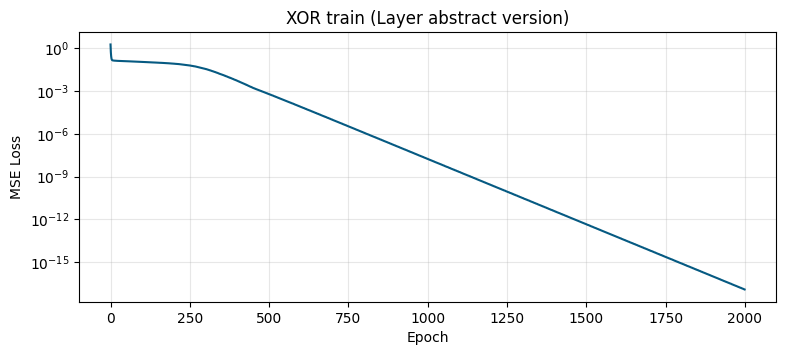

In [6]:
# XOR 데이터
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
Y_xor = np.array([[0], [1], [1], [0]], dtype=float)

# 네트워크 조립 (Keras 스타일!)
net = Network()
net.add(Dense(2, 4, seed=42))
net.add(ReLU())
net.add(Dense(4, 1, seed=43))

loss_fn = MSELoss()

# 학습 루프 — 미니배치를 통째로 forward/backward
history = []
for epoch in range(2000):
    pred = net.forward(X_xor)
    loss = loss_fn.forward(pred, Y_xor)
    grad = loss_fn.backward()
    net.backward(grad)
    net.update(lr=0.1)
    history.append(loss)

# 결과 확인
print("학습 후 예측:")
pred = net.forward(X_xor)
for x, y, p in zip(X_xor, Y_xor, pred):
    print(f"  x={x}, 정답={y[0]}, 예측={p[0]:.4f}")

# Loss curve
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(history, color='#065A82', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('XOR train (Layer abstract version)')
ax.set_yscale('log'); ax.grid(alpha=0.3)
plt.show()

**관찰**: Week 11과 동일한 결과를, **훨씬 일반적인 코드**로 얻었습니다. 

이제 구조를 바꾸기 쉽다는 걸 보여주기 위해 — 위 셀의 `Dense(2, 4)`를 `Dense(2, 8)`로, `Dense(4, 1)`을 `Dense(8, 1)`로 바꿔 실행해 보세요. 한 줄 수정으로 "2-8-1" 네트워크가 됩니다.

---
## 예제 4: Sigmoid vs ReLU — Vanishing Gradient 실험

10층 네트워크에서 첫 층의 gradient 크기가 어떻게 다른지 직접 측정합니다.

In [7]:
def make_deep_net(activation_class, n_layers=10, hidden=20):
    """동일한 깊이의 네트워크를 두 가지 활성화로."""
    np.random.seed(0)  # 동일한 초기화
    net = Network()
    net.add(Dense(hidden, hidden))
    for _ in range(n_layers - 1):
        net.add(activation_class())
        net.add(Dense(hidden, hidden))
    return net

# 두 네트워크 만들기
net_sig  = make_deep_net(Sigmoid, n_layers=10)
net_relu = make_deep_net(ReLU,    n_layers=10)

# 동일한 입력 + 임의 gradient → 첫 층의 dW 절댓값 비교
x = np.random.randn(32, 20)
y_dummy = np.random.randn(32, 20)

for name, net in [('Sigmoid', net_sig), ('ReLU', net_relu)]:
    out = net.forward(x)
    grad = (out - y_dummy) / len(x)
    net.backward(grad)
    
    first_dense = net.layers[0]  # 첫 Dense layer
    grad_norm = np.abs(first_dense.dW).mean()
    print(f"{name:8s} 첫 층 gradient 평균 절댓값: {grad_norm:.2e}")

Sigmoid  첫 층 gradient 평균 절댓값: 5.03e-06
ReLU     첫 층 gradient 평균 절댓값: 1.88e-01


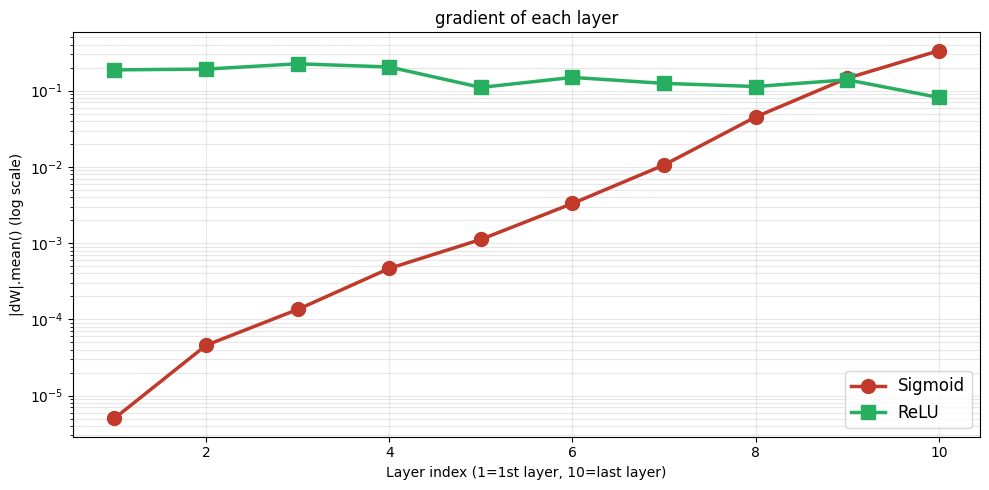


ReLU 첫 층 gradient는 Sigmoid보다 약 37278배 큼


In [9]:
# 시각화: 층별 gradient 크기 (모든 층의 dW를 측정)
def measure_layer_grads(net):
    """각 Dense layer의 dW 평균 절댓값 리스트."""
    return [np.abs(L.dW).mean() for L in net.layers if isinstance(L, Dense)]

grads_sig = measure_layer_grads(net_sig)
grads_relu = measure_layer_grads(net_relu)

fig, ax = plt.subplots(figsize=(10, 5))
layer_idx = np.arange(1, len(grads_sig) + 1)
ax.semilogy(layer_idx, grads_sig, 'o-', color='#C0392B', linewidth=2.5,
            markersize=10, label='Sigmoid')
ax.semilogy(layer_idx, grads_relu, 's-', color='#27AE60', linewidth=2.5,
            markersize=10, label='ReLU')
ax.set_xlabel('Layer index (1=1st layer, 10=last layer)')
ax.set_ylabel('|dW|.mean() (log scale)')
ax.set_title('gradient of each layer')
ax.legend(fontsize=12); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

ratio = grads_relu[0] / grads_sig[0]
print(f"\nReLU 첫 층 gradient는 Sigmoid보다 약 {ratio:.0f}배 큼")

**관찰**: 
- Sigmoid: 첫 층의 gradient가 거의 0 (vanishing!)
- ReLU: 모든 층에서 일정한 크기의 gradient 유지

이것이 ReLU가 현대 딥러닝의 기본 활성화가 된 이유입니다.

---
## 예제 5: Iris 분류 

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 로드
iris = load_iris()
X = iris.data    # (150, 4)
y = iris.target  # (150,) 0, 1, 2 클래스

# 표준화 + one-hot
scaler = StandardScaler()
X = scaler.fit_transform(X)
Y = np.eye(3)[y]  # (150, 3) one-hot

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"클래스 비율: {Y_train.sum(axis=0)}")

Train: (105, 4), Test: (45, 4)
클래스 비율: [35. 35. 35.]


In [11]:
# 네트워크 조립: 4 → 8 → 3 (logit까지만 — Softmax는 loss에 내장)
net = Network()
net.add(Dense(4, 8))
net.add(ReLU())
net.add(Dense(8, 3))

loss_fn = SoftmaxCE()  # Softmax + CrossEntropy 결합

# 학습 — fit() 함수 사용
history = fit(net, X_train, Y_train, loss_fn,
              epochs=100,
              batch_size=16,
              lr=0.05,
              verbose=True)

# 정확도 평가
train_acc = (net.forward(X_train).argmax(axis=1) == Y_train.argmax(axis=1)).mean()
test_acc  = (net.forward(X_test).argmax(axis=1)  == Y_test.argmax(axis=1)).mean()

print(f"\n최종 결과:")
print(f"  Train accuracy: {train_acc:.1%}")
print(f"  Test accuracy:  {test_acc:.1%}")

Epoch    0: loss = 1.850472
Epoch   10: loss = 0.430047
Epoch   20: loss = 0.317638
Epoch   30: loss = 0.250929
Epoch   40: loss = 0.207279
Epoch   50: loss = 0.174646
Epoch   60: loss = 0.160879
Epoch   70: loss = 0.134666
Epoch   80: loss = 0.123381
Epoch   90: loss = 0.102629

최종 결과:
  Train accuracy: 96.2%
  Test accuracy:  97.8%


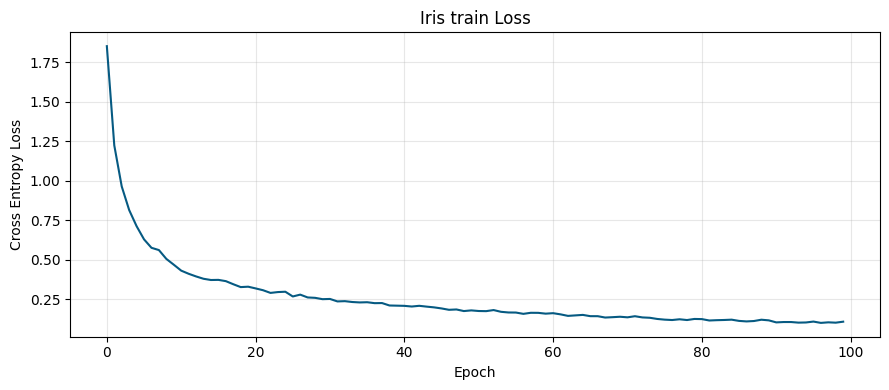

In [13]:
# 시각화
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history['loss'], color='#065A82', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross Entropy Loss')
ax.set_title('Iris train Loss'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 예제 6: MNIST 손글씨 인식

**수업 슬라이드 26-28과 대응**

이번에는 진짜 "deep" 네트워크를 미니배치로 학습합니다.

(시간 절약을 위해 60K 중 일부만 사용. 전체로 돌리려면 epochs=20 권장)

In [15]:
# MNIST 로드 — 여러 소스를 차례로 시도 (네트워크 끊겨도 캐시되어 있으면 동작)
import os

X = y = None

# 1) torchvision (PyTorch 환경에 보통 함께 설치됨, 별도 서버에서 받음)
if X is None:
    try:
        from torchvision import datasets
        print("torchvision으로 MNIST 로딩 시도...")
        root = os.path.expanduser("~/.cache/mnist")
        train = datasets.MNIST(root, train=True,  download=True)
        test  = datasets.MNIST(root, train=False, download=True)
        X = np.concatenate([train.data.numpy(), test.data.numpy()]).reshape(-1, 784)
        y = np.concatenate([train.targets.numpy(), test.targets.numpy()])
        print("  ✓ torchvision 성공")
    except Exception as e:
        print(f"  ✗ torchvision 실패: {type(e).__name__}")

# 2) keras.datasets (TF/Keras 설치되어 있다면)
if X is None:
    try:
        from tensorflow.keras.datasets import mnist as keras_mnist
        print("Keras로 MNIST 로딩 시도...")
        (X_tr, y_tr), (X_te, y_te) = keras_mnist.load_data()
        X = np.concatenate([X_tr, X_te]).reshape(-1, 784)
        y = np.concatenate([y_tr, y_te])
        print("  ✓ Keras 성공")
    except Exception as e:
        print(f"  ✗ Keras 실패: {type(e).__name__}")

# 3) sklearn fetch_openml (인터넷 필요, 위에서 본 방법)
if X is None:
    try:
        from sklearn.datasets import fetch_openml
        print("OpenML로 MNIST 로딩 시도...")
        mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
        X = mnist.data
        y = mnist.target.astype(int)
        print("  ✓ OpenML 성공")
    except Exception as e:
        print(f"  ✗ OpenML 실패: {type(e).__name__}")

if X is None:
    raise RuntimeError(
        "MNIST를 불러올 수 없습니다. 다음 중 하나를 시도하세요:\n"
        "  - 인터넷 연결 확인\n"
        "  - pip install torchvision\n"
        "  - pip install tensorflow")

# 정규화 + one-hot
X = X.astype(np.float32) / 255.0
Y = np.eye(10)[y]

# 빠른 데모를 위해 부분만 사용 (앞 60K = train 풀, 뒤 10K = test 풀)
n_train, n_test = 10000, 2000
X_train = X[:n_train]
Y_train = Y[:n_train]
X_test  = X[60000:60000+n_test]
Y_test  = Y[60000:60000+n_test]

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

torchvision으로 MNIST 로딩 시도...


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 162kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.77MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.26MB/s]


  ✓ torchvision 성공

Train: (10000, 784), Test: (2000, 784)


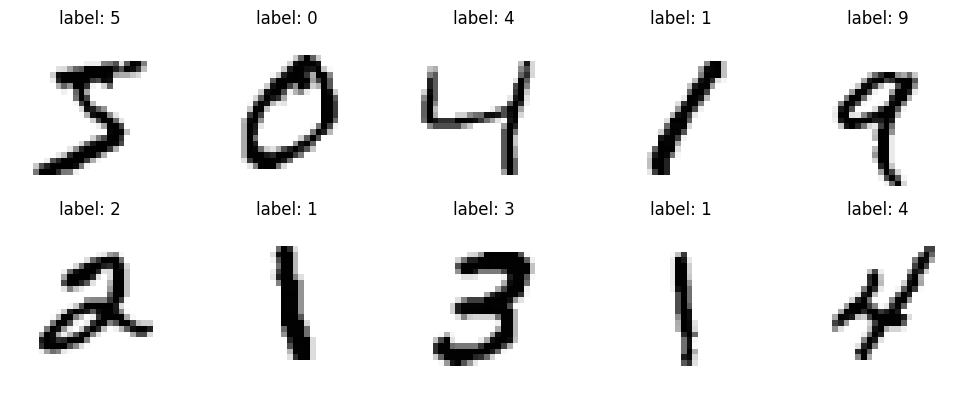

In [16]:
# MNIST 샘플 시각화
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"label: {Y_train[i].argmax()}")
    ax.axis('off')
plt.tight_layout(); plt.show()

In [17]:
# 네트워크: 784 → 128 → 64 → 10 (logit까지만)
np.random.seed(42)
net = Network()
net.add(Dense(784, 128))
net.add(ReLU())
net.add(Dense(128, 64))
net.add(ReLU())
net.add(Dense(64, 10))

loss_fn = SoftmaxCE()

# 파라미터 수
n_params = sum(L.W.size + L.b.size for L in net.layers if isinstance(L, Dense))
print(f"총 파라미터 수: {n_params:,}")

총 파라미터 수: 109,386


In [18]:
# Mini-batch 학습 — fit() 사용 + 매 epoch 마다 test accuracy 측정
import time

def fit_with_test_acc(net, X, Y, X_test, Y_test, loss_fn,
                       epochs=10, batch_size=64, lr=0.01):
    """교재의 fit()에 test accuracy 기록을 추가한 버전."""
    n = len(X)
    history = {'loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        epoch_loss = 0
        n_batches = 0
        
        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            logits = net.forward(X[b])
            loss = loss_fn.forward(logits, Y[b])
            net.backward(loss_fn.backward())
            net.update(lr)
            epoch_loss += loss
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        test_acc = (net.forward(X_test).argmax(axis=1) == Y_test.argmax(axis=1)).mean()
        history['loss'].append(avg_loss)
        history['test_acc'].append(test_acc)
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1:2d}: loss={avg_loss:.4f}, test_acc={test_acc:.1%}")
    
    return history

t0 = time.time()
history = fit_with_test_acc(net, X_train, Y_train, X_test, Y_test, loss_fn,
                             epochs=10, batch_size=64, lr=0.01)
print(f"\n총 학습 시간: {time.time() - t0:.1f}초")
print(f"최종 test 정확도: {history['test_acc'][-1]:.1%}")

Epoch  2: loss=0.9648, test_acc=78.4%
Epoch  4: loss=0.4851, test_acc=84.7%
Epoch  6: loss=0.3762, test_acc=86.9%
Epoch  8: loss=0.3293, test_acc=87.5%
Epoch 10: loss=0.2939, test_acc=88.4%

총 학습 시간: 1.9초
최종 test 정확도: 88.4%


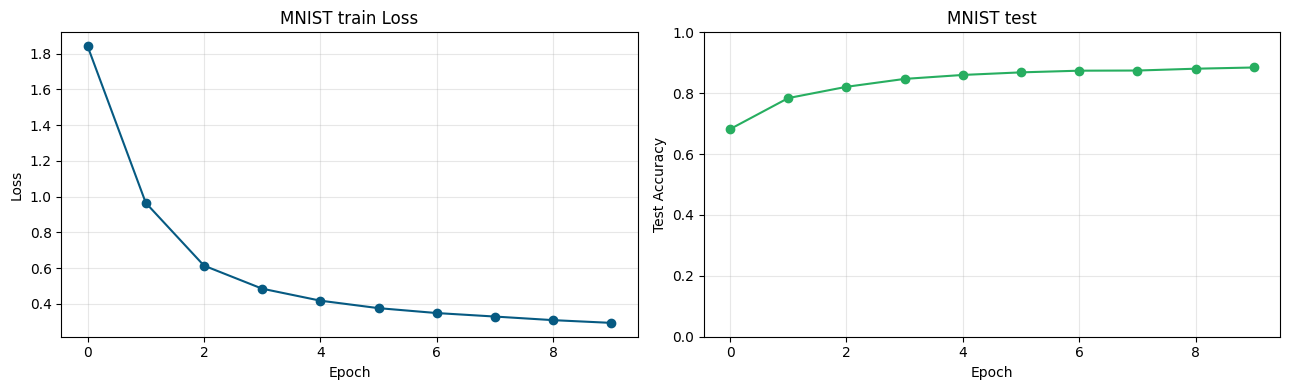

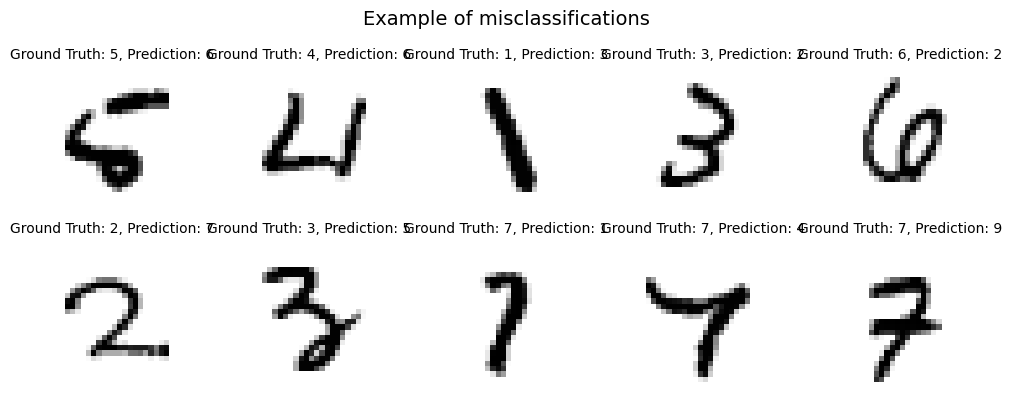

In [21]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['loss'], 'o-', color='#065A82', linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('MNIST train Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(history['test_acc'], 'o-', color='#27AE60', linewidth=1.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('MNIST test'); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout(); plt.show()

# 잘못 분류한 예시
preds = net.forward(X_test).argmax(axis=1)
true = Y_test.argmax(axis=1)
wrong_idx = np.where(preds != true)[0]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    if i < len(wrong_idx):
        idx = wrong_idx[i]
        ax.imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
        ax.set_title(f"Ground Truth: {true[idx]}, Prediction: {preds[idx]}", fontsize=10)
    ax.axis('off')
plt.suptitle('Example of misclassifications', fontsize=14)
plt.tight_layout(); plt.show()